<a href="https://colab.research.google.com/github/KavyaPatel03/Titanic/blob/main/Titanic_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [ ]:
data = pd.read_csv('titanic.csv')

In [ ]:
# Question 1 - How many Passengers survived?
data['Survived'].value_counts()

,count
Survived,
0,549
1,342


The above result shows that how many passengers survived(1) and how many didn't survived(0).Only 38.38% people survived which is considered very bad as the Titanic was considered as one of the most advanced and safest ship of that time.

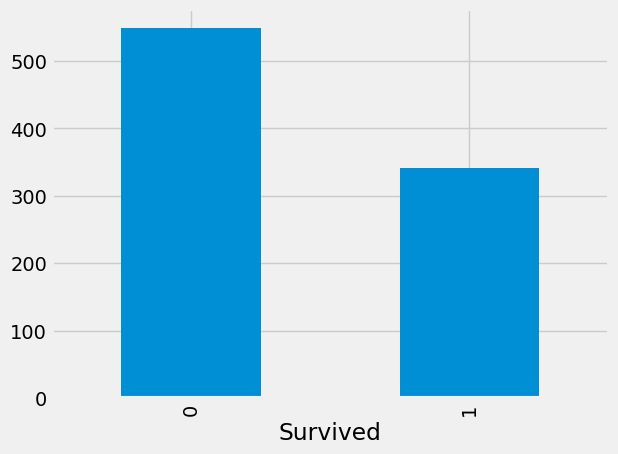

In [ ]:
t1 = data['Survived'].value_counts()
t1.plot(kind = 'bar')
plt.show()

In [ ]:
#Question 2 - How many Male and Female survived?
data.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

The above result shows that how many male and how many female has survived.Only 34.76% female died during the breakdown of the Titanic which is considered a small amount in comparision to the percentage of male passesnger died which is 81.10%.It is almost 3 times the number of death of female passengers.

This analysis shows that female were given more priority at the time of breakdown above men.

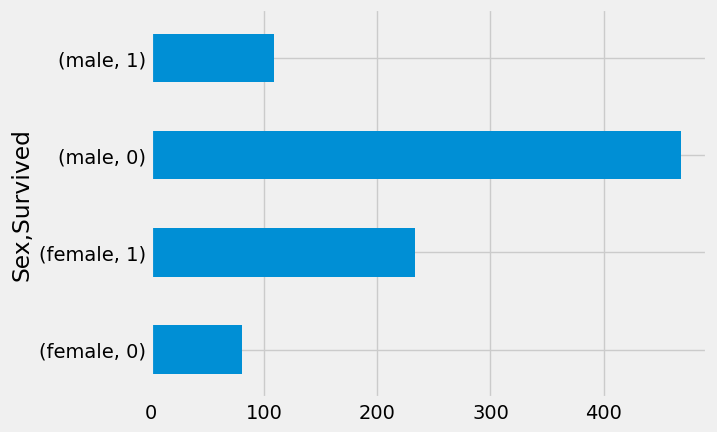

In [ ]:
t1 = data.groupby(['Sex','Survived'])['Survived'].count()
t1.plot(kind = 'barh')
plt.show()

In [ ]:
#Question 3 - How many People survived from each class?
pd.pivot_table(data=data, index='Pclass', values='Survived',aggfunc='sum')

,Survived
Pclass,
1,136
2,87
3,119


It Shows that how many people has survived from each class.


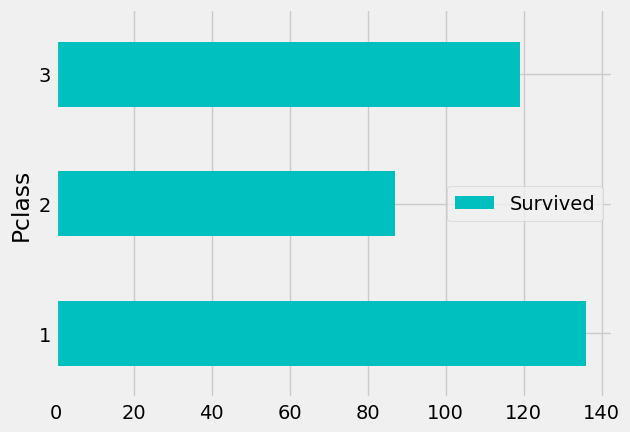

In [ ]:
t1 = pd.pivot_table(data=data, index='Pclass', values='Survived',aggfunc='sum')
colour = ['c']
t1.plot(kind = 'barh',color = colour)
plt.show()

In [ ]:
#Question 4 - How many people travelled through each class?
data['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


It shows that total how many passengers has travelled through each class or section.

From the result of question 3, we can assess that even if the number of passenger survived from class 3 is higher than class 2 but in reality the percentage of people didn't survived in the class 3 is around 75% whereas the percentage of people didn't survived in the class 2 is  53% which is a very important detail.

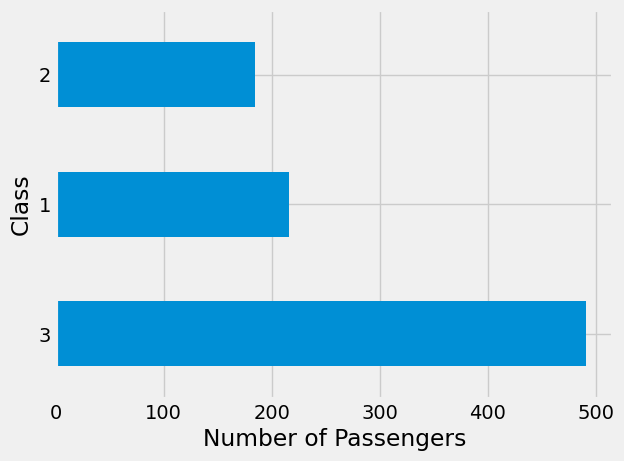

In [ ]:
t1 = data['Pclass'].value_counts()
t1.plot(kind = 'barh')
plt.xlabel('Number of Passengers')
plt.ylabel('Class')
plt.show()

In [ ]:
#Question 5 - How many male and female survived from each class?
pd.crosstab([data.Sex,data.Survived],data.Pclass,margins=True)

Pclass             1    2    3  All
Sex    Survived                    
female 0           3    6   72   81
       1          91   70   72  233
male   0          77   91  300  468
       1          45   17   47  109
All              216  184  491  891

It shows that how many male and female died and how many were saved.

We can see, in the first class only 3 women died whereas number of men died in the first class is 77 which is 26 times more than number of females died and the conditions were even worse in the second and third class in terms of numbers.

In the case of survival, women were given priority over men as we see than number of women survived is twice the number of men survived.

So, at the end we can draw the conclusion that it is more beneficial to travel with the first class as it comes with priority.

In [ ]:
#Question 6 - What was the maximum, minimum,and average age of the passenger on the titanic?
print('Oldest Passenger was of:',data['Age'].max(),'Years')
print('Youngest Passenger was of:',data['Age'].min(),'Years')
print('Average Age on the ship:',data['Age'].mean(),'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.69911764705882 Years


It shows the average age of passengers,the age of the oldest passenger and the age of the youngest passenger.

We can conclude that because of this event the country lost many earning people which is not a good sign.

In [ ]:
#Question 7 - What was the average age of every category of person on the titanic?
data['Initial']=0
for i in data:
    data['Initial']=data.Name.str.extract('([A-Za-z]+)\.')
data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)
data.groupby('Initial')['Age'].mean()


,Age
Initial,
Master,4.574167
Miss,21.860000
Mr,32.739609
Mrs,35.981818
Other,45.888889


In [ ]:
data['Initial'] = data['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)
initial_mapping = {
    'Mlle': 'Miss', 'Mme': 'Miss', 'Ms': 'Miss',
    'Dr': 'Mr', 'Major': 'Mr', 'Sir': 'Mr', 'Don': 'Mr', 'Capt': 'Mr',
    'Lady': 'Mrs', 'Countess': 'Mrs',
    'Jonkheer': 'Other', 'Col': 'Other', 'Rev': 'Other'}
data['Initial'] = data['Initial'].replace(initial_mapping)
data.groupby('Initial')['Age'].mean()

,Age
Initial,
Master,4.574167
Miss,21.860000
Mr,32.739609
Mrs,35.981818
Other,45.888889


It shows the average age of every age bracket.

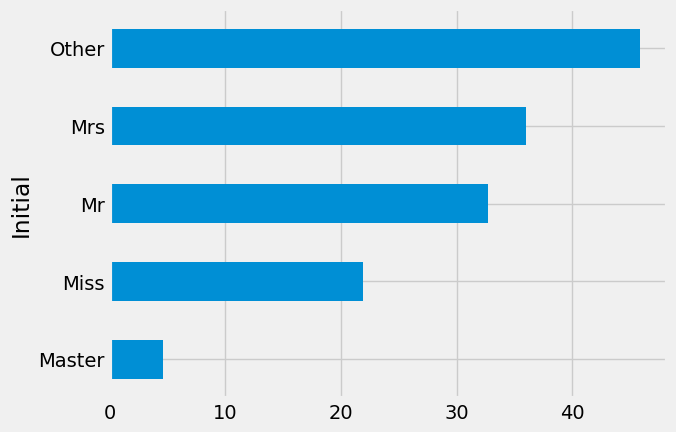

In [ ]:
data['Initial'] = data.Name.str.extract('([A-Za-z]+)\.')
data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)
t1 = data.groupby('Initial')['Age'].mean()
t1.plot(kind = 'barh')
plt.show()

In [ ]:
#Question 8 - How to fill the null values in the age column?
data.loc[(data.Age.isnull()) & (data.Initial== 'Mr')] = 33
data.loc[(data.Age.isnull()) & (data.Initial== 'Mrs')] = 36
data.loc[(data.Age.isnull()) & (data.Initial == 'Master')] = 5
data.loc[(data.Age.isnull()) & (data.Initial == 'Miss')] = 22
data.loc[(data.Age.isnull()) & (data.Initial == 'Other')] = 46
data.Age.isnull().any()

np.False_

It sets every null cell with their derived average age according to the preffix of their names.


In [ ]:
#Question 9 - Which age group people died the most?
data[data['Survived'] == 0]['Age'].value_counts()

,count
Age,
21.0,19
28.0,18
18.0,17
25.0,17
19.0,16
...,...
15.0,1
24.5,1
6.0,1


It shows that how many passenger have survived of which age.

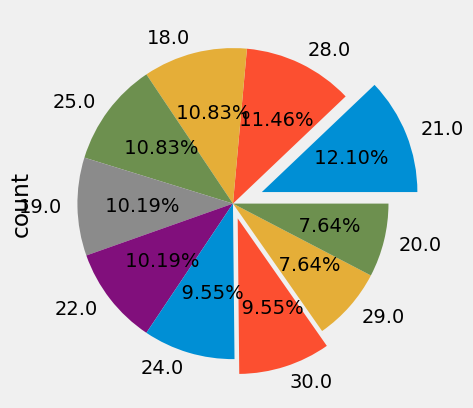

In [ ]:
t1 = data[data['Survived'] == 0]['Age'].value_counts().head(10)
expl = [0.2,0,0,0,0,0,0,0.1,0,0]
t1.plot(kind = 'pie',autopct = '%6.2f%%',explode = expl)
plt.show()

In [ ]:
#Question 10 - How many male and female died and survived from the gate they entered and from which class the were?
pd.crosstab([data.Embarked,data.Pclass],[data.Sex,data.Survived],margins=True).tail(10)

Sex              5  22   33  36 female      male      All
Survived         5  22   33  36      0    1    0   1     
Embarked Pclass                                          
C        1       0   0    0   0      1   37   20  16   74
         2       0   0    0   0      0    7    7   1   15
         3       0   0    0   0      5   11   18   7   41
Q        1       0   0    0   0      0    1    1   0    2
         2       0   0    0   0      0    1    1   0    2
         3       0   0    0   0      5    5   13   1   24
S        1       0   0    0   0      2   42   40  24  108
         2       0   0    0   0      6   60   76  14  156
         3       0   0    0   0     45   31  184  30  290
All              4  36  120  17     64  195  360  93  889

In [ ]:
data.pivot_table(
    index=['Embarked', 'Pclass'],
    columns=['Sex', 'Survived'],
    values='Name', # Can be any column name, used for counting
    aggfunc='count',
    margins=True
).tail(10)

Sex                5    22     33    36 female          male        All
Survived           5    22     33    36      0      1      0     1     
Embarked Pclass                                                        
C        1       NaN   NaN    NaN   NaN    1.0   37.0   20.0  16.0   74
         2       NaN   NaN    NaN   NaN    NaN    7.0    7.0   1.0   15
         3       NaN   NaN    NaN   NaN    5.0   11.0   18.0   7.0   41
Q        1       NaN   NaN    NaN   NaN    NaN    1.0    1.0   NaN    2
         2       NaN   NaN    NaN   NaN    NaN    1.0    1.0   NaN    2
         3       NaN   NaN    NaN   NaN    5.0    5.0   13.0   1.0   24
S        1       NaN   NaN    NaN   NaN    2.0   42.0   40.0  24.0  108
         2       NaN   NaN    NaN   NaN    6.0   60.0   76.0  14.0  156
         3       NaN   NaN    NaN   NaN   45.0   31.0  184.0  30.0  290
All              4.0  36.0  120.0  17.0   64.0  195.0  360.0  93.0  889

In [ ]:
#Question 11
data['Embarked'].fillna('S',inplace= True)
data.Embarked.isnull().any()

np.False_

In [ ]:
#Question 12 - How many people survived and died who were there with their sibling or a spouse?
pd.crosstab([data.SibSp],[data.Survived])

Survived,0,1,5,22,33,36
SibSp,,,,,,
0,296,175,0,0,0,0
1,86,97,0,0,0,0
2,14,11,0,0,0,0
3,8,4,0,0,0,0
4,15,3,0,0,0,0
5,5,0,4,0,0,0
22,0,0,0,36,0,0
33,0,0,0,0,120,0
36,0,0,0,0,0,17


It shows that how many people with siblings or spouse survived.


In [ ]:
#question 13 - How many people survived from each class who were there with their sibling or a spouse?
pd.crosstab(data.SibSp,data.Pclass)

Pclass,1,2,3,5,22,33,36
SibSp,,,,,,,
0,113,109,249,0,0,0,0
1,65,55,63,0,0,0,0
2,5,8,12,0,0,0,0
3,3,1,8,0,0,0,0
4,0,0,18,0,0,0,0
5,0,0,5,4,0,0,0
22,0,0,0,0,36,0,0
33,0,0,0,0,0,120,0
36,0,0,0,0,0,0,17


It shows how many people survived who were with their spouse or sibling and from which class they were.

In [ ]:
#Question 14 - How many people survived who were with their parents and children?
pd.crosstab([data.Parch],[data.Pclass])

Pclass,1,2,3,5,22,33,36
Parch,,,,,,,
0,134,123,264,0,0,0,0
1,30,32,48,0,0,0,0
2,21,16,31,0,0,0,0
3,0,2,3,0,0,0,0
4,1,0,3,0,0,0,0
5,0,0,5,4,0,0,0
6,0,0,1,0,0,0,0
22,0,0,0,0,36,0,0
33,0,0,0,0,0,120,0


It shows that how many people survived who were with their parents and children.

In [ ]:
#Question 15 - What is the maximum, minimum, and average fare of the titanic?
print('Highest Fare', data['Fare'].max())
print('Lowest Fare',data['Fare'].min())
print('Average Fare',data['Fare'].mean())

Highest Fare 512.3292
Lowest Fare 0.0
Average Fare 32.204207968574636


It shows the average fare,the highest fare charged and the least fare charged.It shows you the difference as it would be obvious that the highest fare would be of 1s class and the lowest will be of the 3rd class.